# Step - 1: Set up and Data Exploration

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             roc_curve, roc_auc_score, recall_score, f1_score, precision_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data Acquisition: Download a suitable dataset (IBM Watson Telco Customer Churn dataset)
df = pd.read_csv("../data/Telco_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Exploratory Data Analysis (EDA): Analyze data types
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Dataset Shape: (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [4]:
# Basic statistics
print("\nBasic Statistics:\n", df.describe())


Basic Statistics:
        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Converting 'TotalCharges' column to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Churn
No     5174
Yes    1869
Name: count, dtype: int64


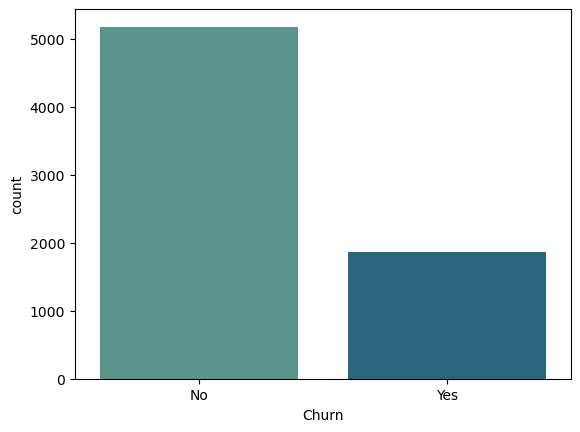

In [7]:
# Visualize distributions of the target variable
print(df['Churn'].value_counts())
sns.countplot(x='Churn', data=df, palette='crest')
plt.show()

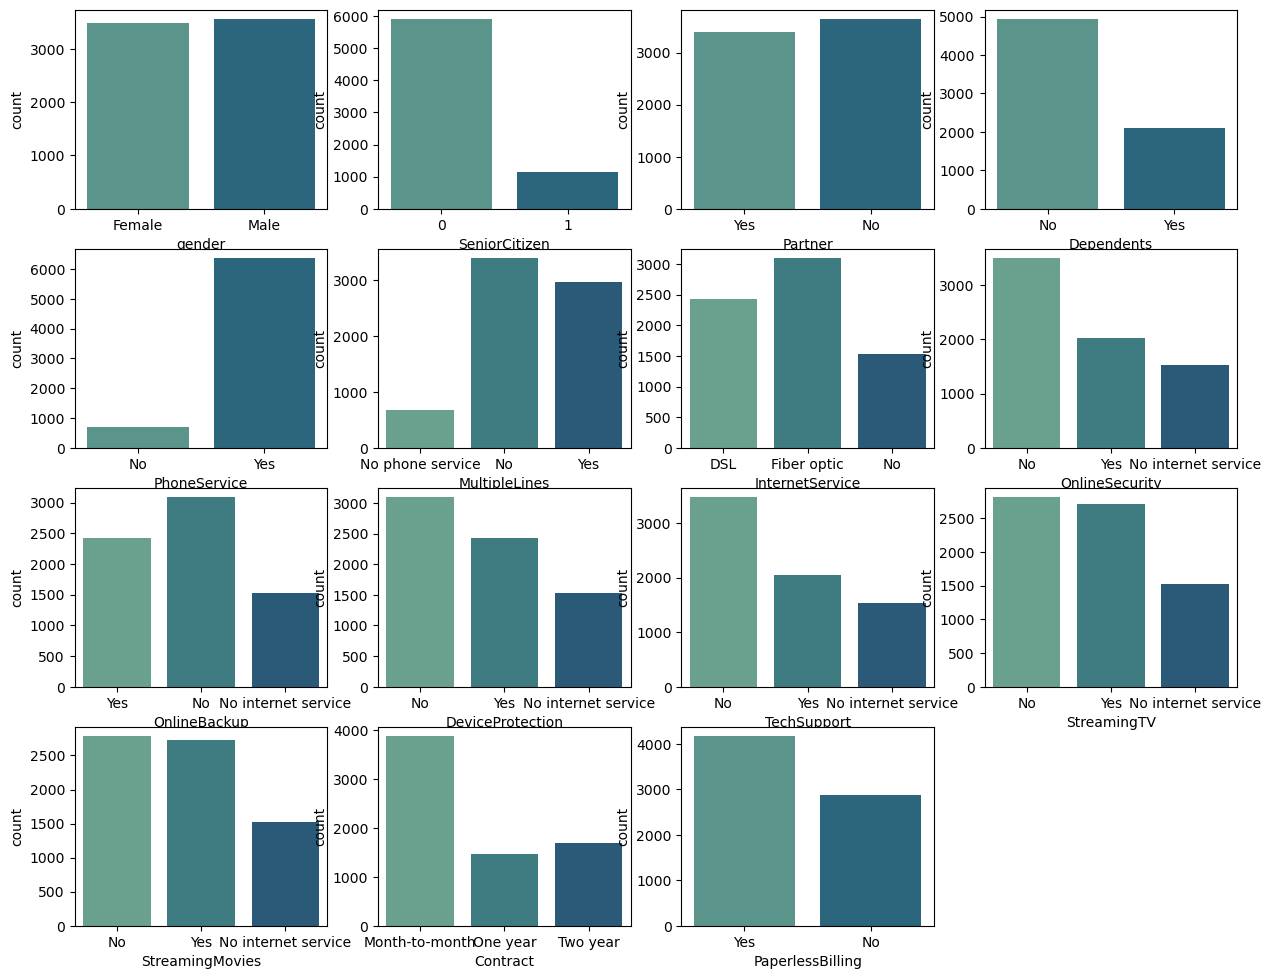

In [8]:
# Visualize categorical features
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService',
              'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaperlessBilling']

plt.figure(figsize=(15, 15))
for n, variable in enumerate(cat_cols):
    ax = plt.subplot(5, 4, n + 1)
    sns.countplot(data=df, x=df[variable], ax=ax, palette='crest')
plt.show() 

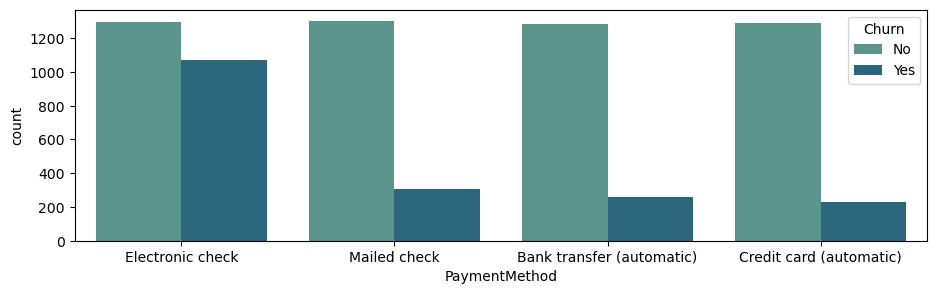

In [9]:
plt.figure(figsize=(11,3))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='crest')
plt.show() 

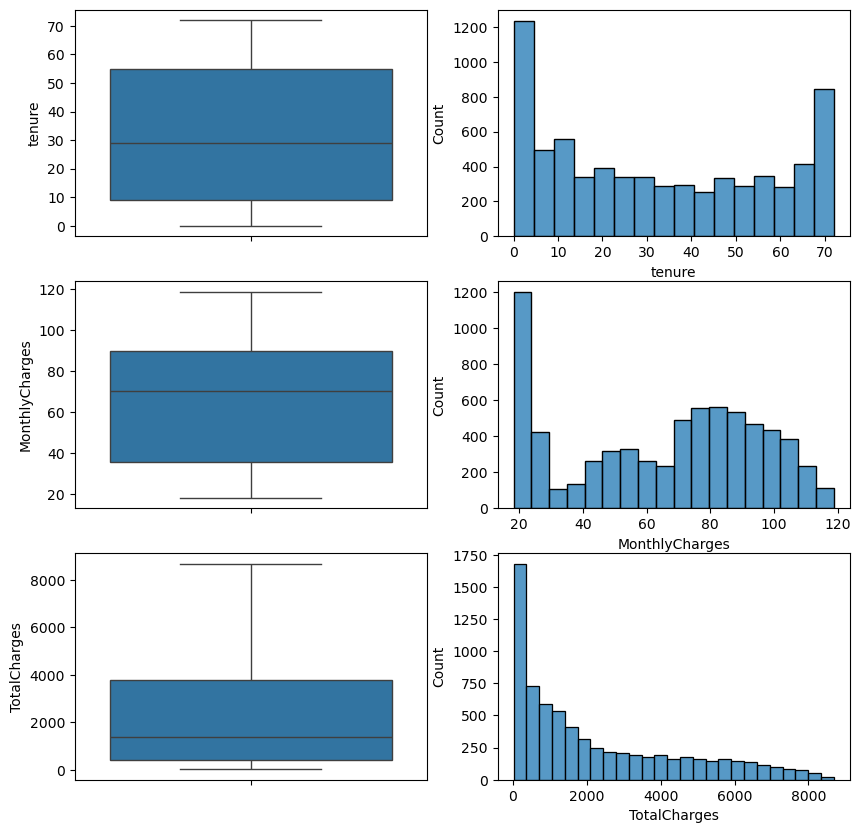

In [10]:
plt.figure(figsize=(10,10))
plt.subplot(3, 2, 1)
_ = sns.boxplot(y=df['tenure'])
plt.subplot(3, 2, 2)
_ = sns.histplot(x='tenure', data=df)

plt.subplot(3, 2, 3)
_ = sns.boxplot(y= df['MonthlyCharges'])
plt.subplot(3, 2, 4)
_ = sns.histplot(x='MonthlyCharges', data=df)

plt.subplot(3, 2, 5)
_ = sns.boxplot(y=df['TotalCharges'])
plt.subplot(3, 2, 6)
_ = sns.histplot(x='TotalCharges', data=df)

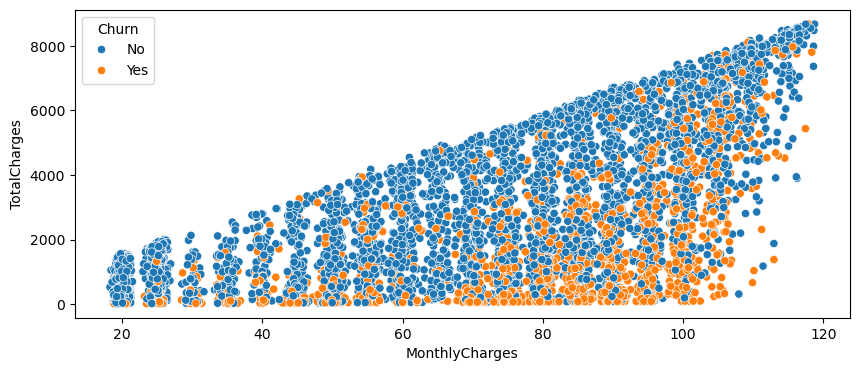

In [11]:
# Scatter plot of Monthly Charges versus Total Charges
plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn')
plt.show()

# Step - 2: Data Preprocessing & Feature Engineering

In [12]:
# Separate 20% of the data for testing (for model evaluation on totally unseen data)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Churn'])
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [13]:
# Data Cleaning: Address missing values
display(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


None

In [14]:
# Check and handling missing values
print(train_df.isna().sum())

# Fill with Mean value (imputation)
train_df['TotalCharges'].fillna((train_df['TotalCharges'].mean()), inplace=True)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
Churn               0
dtype: int64


In [15]:
# Check for duplicates
print(train_df.duplicated().sum())

# Replace 'No internet service' and 'No phone service' with 'No'
train_df.replace(['No internet service','No phone service'], 'No', inplace=True)

0


In [16]:
# Encode categorical variables (One-Hot Encoding, Label Encoding)
cat_cols = ['gender', 'InternetService','PaymentMethod','Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines', 'OnlineSecurity', 
          'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']

# One-hot encoding
train_df = pd.concat([train_df, pd.get_dummies(train_df[cat_cols])], axis='columns')
train_df = train_df.drop(columns=cat_cols)

# Label encoding for target feature
train_df['Churn'] = np.where(train_df['Churn'] == 'Yes', 1, 0)

In [17]:
# Identify numeric columns to scale (excluding binary/dummy columns)
numeric_cols = ['MonthlyCharges', 'TotalCharges']

# Log transform before scaling (keep as is, then scale)
for col in numeric_cols:
    train_df[col] = np.log1p(train_df[col])

# Initialize StandardScaler
scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])

In [18]:
# Feature engineering - Binning 'tenure' feature into 6 ranges
condition = [((train_df.tenure >= 0)&(train_df.tenure <= 12)), ((train_df.tenure > 12)&(train_df.tenure <= 24)), 
                ((train_df.tenure > 24)&(train_df.tenure <= 36)),((train_df.tenure > 36)&(train_df.tenure <= 48)),
                ((train_df.tenure > 48)&(train_df.tenure <= 60)), (train_df.tenure > 60)]
choice = [0, 1, 2, 3, 4, 5]
train_df['tenure_range'] = np.select(condition, choice)

In [19]:
# Prepare features and target for training
X_train = train_df.drop(columns=['customerID','Churn'])
y_train = train_df['Churn']

# Handling data imbalance using SMOTE
sm = SMOTE(random_state=0, sampling_strategy='minority', k_neighbors=5)
X_train, y_train = sm.fit_resample(X_train, y_train.ravel())
print(f"After SMOTE - Class distribution:\n{pd.Series(y_train).value_counts()}")

After SMOTE - Class distribution:
0    4139
1    4139
Name: count, dtype: int64


In [20]:
# Preprocessing function on Test set (apply all previous preprocessing steps on the test set)
def test_prep(test_df):
    # Data cleaning
    test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')

    # Fill with Mean value
    test_df['TotalCharges'].fillna((test_df['TotalCharges'].mean()), inplace=True)
    
    # Replace 'No internet service' and 'No phone service' with 'No'
    test_df.replace(['No internet service','No phone service'], 'No', inplace=True)
    
    # If there are null values in the continuous features --> fill with the mean of columns in training set (mapping)
    for col in test_df.columns:
        if test_df[col].isna().sum() > 0:
            test_df[col] = test_df[col].fillna(train_df[col].map(np.mean))
    
    # Categorical features encoding 
    test_df = pd.concat([test_df, pd.get_dummies(test_df[cat_cols])], axis='columns')
    test_df = test_df.drop(columns=cat_cols)
    
    test_df['Churn'] = np.where(test_df['Churn'] == 'Yes', 1, 0)
    
    # Feature engineering - Binning 'tenure' feature into 6 ranges
    condition = [((test_df.tenure >= 0)&(test_df.tenure <= 12)), ((test_df.tenure > 12)&(test_df.tenure <= 24)), 
                 ((test_df.tenure > 24)&(test_df.tenure <= 36)),((test_df.tenure > 36)&(test_df.tenure <= 48)),
                 ((test_df.tenure > 48)&(test_df.tenure <= 60)), (test_df.tenure > 60)]
    choice = [0, 1, 2, 3, 4, 5]
    test_df['tenure_range'] = np.select(condition, choice)
    
    # Log transform and scale
    for col in numeric_cols:
        test_df[col] = np.log1p(test_df[col])
    test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

    test_df.dropna(axis='columns')
    
    return test_df

In [21]:
# Apply preprocessing to test set
test_df = test_prep(test_df)
X_test = test_df.drop(columns=['customerID','Churn'])
y_test = test_df['Churn']

In [22]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8278, 39)
(8278,)
(1409, 39)
(1409,)


In [23]:
X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),...,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,tenure_range
0,0,35,-0.224265,0.314262,False,True,True,False,False,False,...,True,False,False,True,False,True,True,False,False,2
1,0,15,0.493069,0.061517,False,True,False,True,False,False,...,True,False,True,False,True,False,True,False,False,1
2,0,13,-0.550346,-0.370720,False,True,True,False,False,False,...,False,True,True,False,True,False,False,False,True,1
3,0,26,0.456431,0.387576,True,False,True,False,False,False,...,True,False,False,True,False,True,False,False,True,2
4,0,1,-0.391867,-2.031205,False,True,True,False,False,False,...,True,False,True,False,True,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8273,0,21,1.026735,0.499107,True,True,False,True,False,True,...,True,False,False,True,False,True,True,False,False,1
8274,0,57,1.022021,1.111403,True,True,False,True,False,False,...,True,False,False,True,False,True,True,False,False,4
8275,0,65,1.049865,1.219844,False,True,False,True,False,False,...,False,True,False,True,False,True,True,True,False,5
8276,0,62,0.983464,1.171069,True,False,False,True,False,False,...,True,False,False,True,False,True,False,True,False,5


# Step - 3: Model Training & Evaluation

## 1. Logistic Regression

In [24]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
model_logReg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
grid_lr = GridSearchCV(model_logReg, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

In [25]:
print(f"Best Logistic Regression params: {grid_lr.best_params_}")
print(f"Best CV F1: {grid_lr.best_score_:.4f}")

Best Logistic Regression params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.8267


In [26]:
# Testing the model
log_pred = best_lr.predict(X_test)

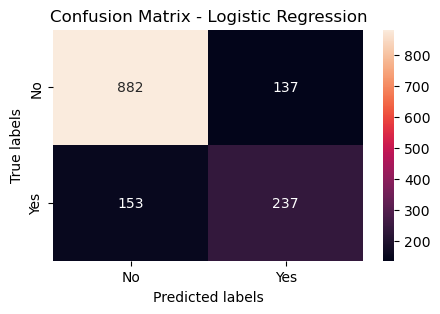

In [27]:
# Confusion Matrix
cm = confusion_matrix(log_pred, y_test)
f, ax = plt.subplots(1,1,figsize=(5,3))
sns.heatmap(cm, annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted labels'); ax.set_ylabel('True labels') 
ax.set_title('Confusion Matrix - Logistic Regression')
ax.xaxis.set_ticklabels(['No', 'Yes']); ax.yaxis.set_ticklabels(['No', 'Yes'])
plt.show()

In [28]:
# Classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_pred, target_names=['No', 'Yes']))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

          No       0.87      0.85      0.86      1035
         Yes       0.61      0.63      0.62       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409



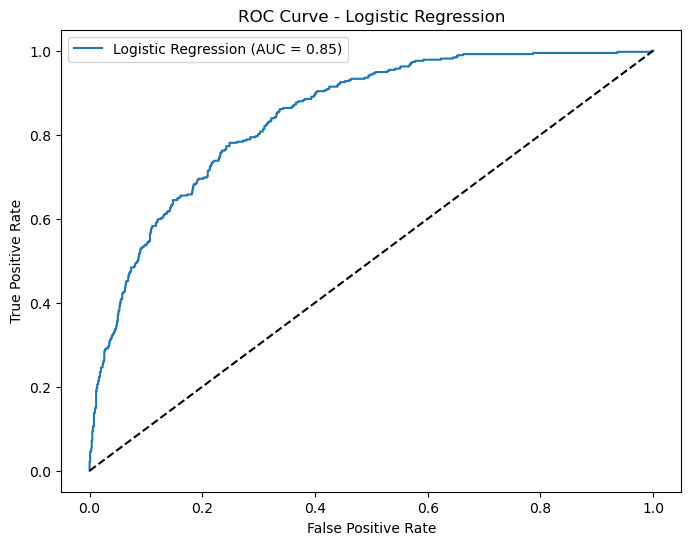

In [29]:
# ROC Curve and AUC
log_probs = best_lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, log_probs)
auc = roc_auc_score(y_test, log_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

## 2. Decision Tree model

In [30]:
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
model_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
grid_dt = GridSearchCV(model_dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

In [31]:
print(f"Best Decision Tree params: {grid_dt.best_params_}")
print(f"Best CV F1: {grid_dt.best_score_:.4f}")

Best Decision Tree params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1: 0.8034


In [32]:
# Testing the model
dt_pred = best_dt.predict(X_test)

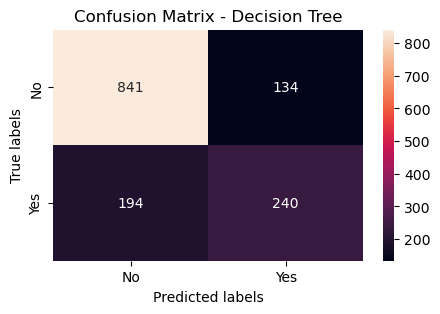

In [33]:
# Confusion Matrix
cm = confusion_matrix(dt_pred, y_test)
f, ax = plt.subplots(1,1,figsize=(5,3))
sns.heatmap(cm, annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted labels'); ax.set_ylabel('True labels') 
ax.set_title('Confusion Matrix - Decision Tree')
ax.xaxis.set_ticklabels(['No', 'Yes']); ax.yaxis.set_ticklabels(['No', 'Yes'])
plt.show()

In [34]:
# Classification report
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['No', 'Yes']))

Decision Tree Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.81      0.84      1035
         Yes       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



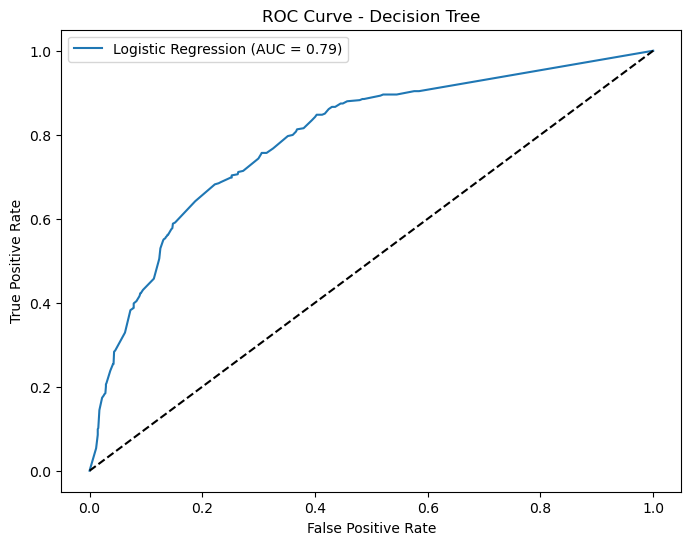

In [35]:
# ROC Curve and AUC
dt_probs = best_dt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, dt_probs)
auc = roc_auc_score(y_test, dt_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

## 3. Random Forest Classifier

In [36]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

In [37]:
print(f"Best Random Forest params: {grid_rf.best_params_}")
print(f"Best CV F1: {grid_rf.best_score_:.4f}")

Best Random Forest params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.8555


In [38]:
# Testing the model
rf_pred = best_rf.predict(X_test)

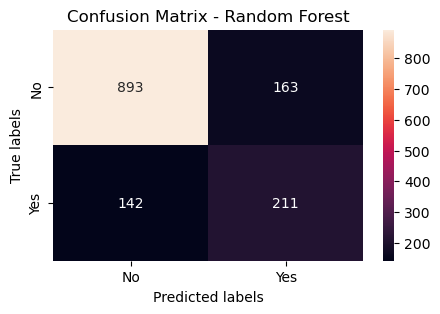

In [39]:
# Confusion Matrix
cm = confusion_matrix(rf_pred, y_test)
f, ax = plt.subplots(1,1,figsize=(5,3))
sns.heatmap(cm, annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted labels'); ax.set_ylabel('True labels') 
ax.set_title('Confusion Matrix - Random Forest')
ax.xaxis.set_ticklabels(['No', 'Yes']); ax.yaxis.set_ticklabels(['No', 'Yes'])
plt.show()

In [40]:
# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['No', 'Yes']))

Random Forest Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.86      0.85      1035
         Yes       0.60      0.56      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



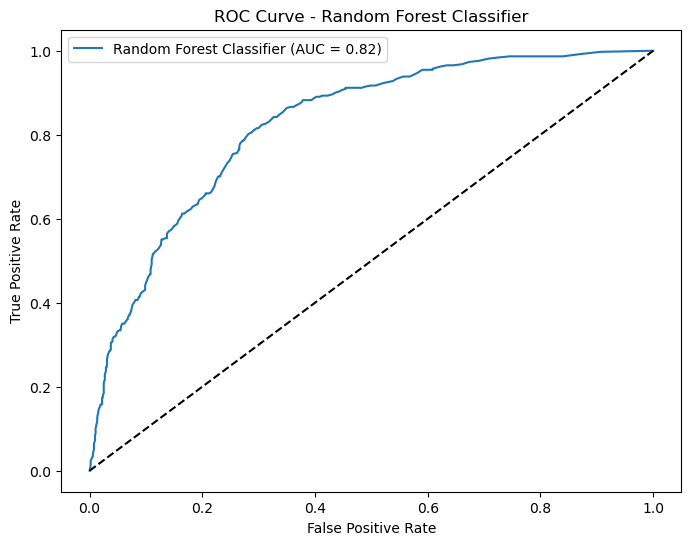

In [41]:
# ROC Curve and AUC
rf_probs = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
auc = roc_auc_score(y_test, rf_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest Classifier (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier')
plt.legend()
plt.show()

In [42]:
# Model Comparison
results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, log_pred),
        'Precision': precision_score(y_test, log_pred),
        'Recall': recall_score(y_test, log_pred),
        'F1-Score': f1_score(y_test, log_pred),
        'ROC-AUC': roc_auc_score(y_test, log_probs)
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, dt_pred),
        'Precision': precision_score(y_test, dt_pred),
        'Recall': recall_score(y_test, dt_pred),
        'F1-Score': f1_score(y_test, dt_pred),
        'ROC-AUC': roc_auc_score(y_test, dt_probs)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred),
        'Recall': recall_score(y_test, rf_pred),
        'F1-Score': f1_score(y_test, rf_pred),
        'ROC-AUC': roc_auc_score(y_test, rf_probs)
    }
}

results_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(results_df.round(3))


=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.794      0.608   0.634     0.620    0.846
Decision Tree           0.767      0.553   0.642     0.594    0.791
Random Forest           0.784      0.598   0.564     0.580    0.824


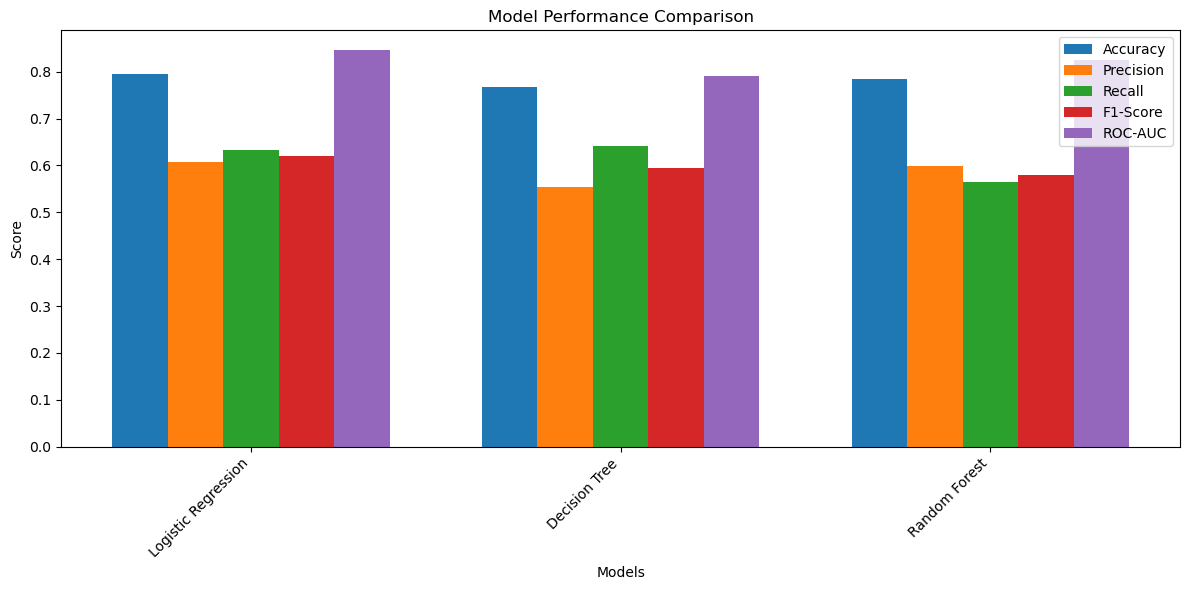

In [43]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df.index))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    values = results_df[metric].values
    ax.bar(x + i*width, values, width, label=metric)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
# Top determining features
feat_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_df.head(10)

,Feature,Importance
1,tenure,0.109861
3,TotalCharges,0.108413
2,MonthlyCharges,0.107418
35,Contract_Month-to-month,0.096188
11,PaymentMethod_Electronic check,0.068400
7,InternetService_Fiber optic,0.044453
38,tenure_range,0.041692
20,PaperlessBilling_Yes,0.029734
23,OnlineSecurity_No,0.026047
37,Contract_Two year,0.022091


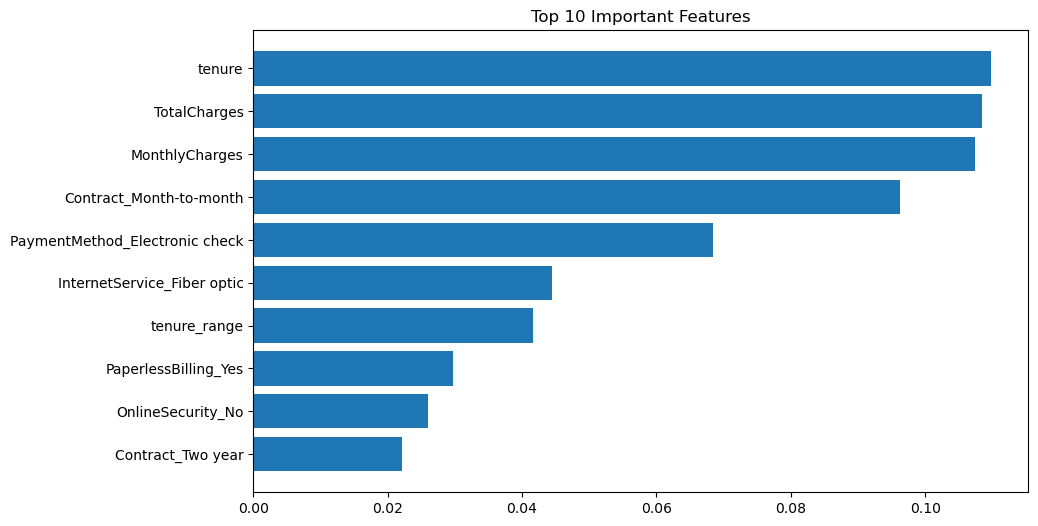

In [46]:
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()